In [ ]:
# ============================================
# MuseMirror AI — V1.1 Setup Cell
# Install required system and Python packages
# ============================================

# System dependency for audio handling
!apt-get -qq install ffmpeg -y

# Python dependencies
!pip install -q \
    librosa \
    soundfile \
    numpy \
    pandas \
    matplotlib \
    openai-whisper \
    gdown

print("✅ Setup complete: all required packages installed successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 10.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.7 MB/s eta 0:00:00
✅ Setup complete: all required packages installed successfully


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Imports & Configuration
# ============================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import whisper

# ----------------------------
# File configuration
# ----------------------------
FILE_ID = "18ZKdVrRHYmjbU6uzAQ88ul3PY7DUTVZN"
FILE_NAME = "Is this what i owe.mp3"
WHISPER_MODEL_SIZE = "medium"   # options: tiny, base, small, medium, large

print("✅ Imports loaded and configuration set")
print(f"Target file name: {FILE_NAME}")
print(f"Whisper model size: {WHISPER_MODEL_SIZE}")

✅ Imports loaded and configuration set
Target file name: Is this what i owe.mp3
Whisper model size: medium


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Download Audio
# ============================================

import os
import gdown

# ----------------------------
# Download from Google Drive
# ----------------------------
if not os.path.exists(FILE_NAME):
    print("⬇️ Downloading audio file...")
    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, FILE_NAME, quiet=False)
else:
    print("⚡ File already exists, skipping download")

# ----------------------------
# Validate file
# ----------------------------
if os.path.exists(FILE_NAME):
    file_size_mb = os.path.getsize(FILE_NAME) / (1024 * 1024)
    print(f"✅ File ready: {FILE_NAME}")
    print(f"📦 Size: {file_size_mb:.2f} MB")
else:
    raise FileNotFoundError("❌ Download failed. File not found.")

# Set path for downstream cells
file_path = FILE_NAME

⬇️ Downloading audio file...


Downloading...
From: https://drive.google.com/uc?id=18ZKdVrRHYmjbU6uzAQ88ul3PY7DUTVZN
To: /content/Is this what i owe.mp3
100%|██████████| 10.9M/10.9M [00:00<00:00, 253MB/s]

✅ File ready: Is this what i owe.mp3
📦 Size: 10.35 MB


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Load Audio
# ============================================

# ----------------------------
# Load audio
# ----------------------------
y, sr = librosa.load(file_path, sr=None, mono=True)

# ----------------------------
# Basic metadata
# ----------------------------
duration_sec = librosa.get_duration(y=y, sr=sr)
total_samples = len(y)
time_axis = np.linspace(0, duration_sec, total_samples)

audio_info = {
    "file_name": file_path,
    "sample_rate": int(sr),
    "duration_sec": float(duration_sec),
    "total_samples": int(total_samples),
    "waveform_shape": tuple(y.shape),
    "peak_amplitude": float(np.max(np.abs(y))),
    "mean_amplitude": float(np.mean(np.abs(y)))
}

print("✅ Audio loaded successfully\n")
print(f"📁 File Name      : {audio_info['file_name']}")
print(f"🎧 Sample Rate    : {audio_info['sample_rate']} Hz")
print(f"⏱️ Duration       : {audio_info['duration_sec']:.2f} sec")
print(f"🔢 Total Samples  : {audio_info['total_samples']}")
print(f"📐 Waveform Shape : {audio_info['waveform_shape']}")
print(f"📈 Peak Amplitude : {audio_info['peak_amplitude']:.6f}")
print(f"📊 Mean Amplitude : {audio_info['mean_amplitude']:.6f}")

✅ Audio loaded successfully

📁 File Name      : Is this what i owe.mp3
🎧 Sample Rate    : 44100 Hz
⏱️ Duration       : 271.18 sec
🔢 Total Samples  : 11958976
📐 Waveform Shape : (11958976,)
📈 Peak Amplitude : 1.330485
📊 Mean Amplitude : 0.122692


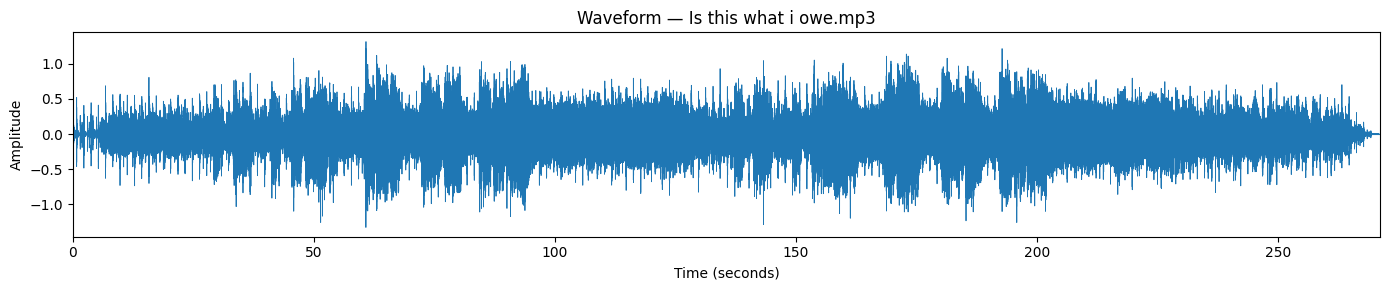

In [ ]:
# ============================================
# MuseMirror AI — V1.1 Waveform Visualization
# ============================================

plt.figure(figsize=(14, 3))
plt.plot(time_axis, y, linewidth=0.6)
plt.axhline(0, linewidth=0.8)

plt.title(f"Waveform — {audio_info['file_name']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.xlim(0, duration_sec)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 6.1
# Beat Tracking + Tempo Interpretation
# ============================================

# ----------------------------
# Detect raw tempo and beat frames
# ----------------------------
tempo_raw, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
tempo_raw_bpm = float(np.asarray(tempo_raw).item())
beat_times_sec = librosa.frames_to_time(beat_frames, sr=sr)

# ----------------------------
# Generate tempo candidates
# ----------------------------
tempo_candidates = {
    "half_time": tempo_raw_bpm / 2,
    "normal": tempo_raw_bpm,
    "double_time": tempo_raw_bpm * 2
}

# Keep only musically reasonable values
valid_tempo_candidates = {
    mode: float(bpm)
    for mode, bpm in tempo_candidates.items()
    if 40 <= bpm <= 220
}

# ----------------------------
# Choose perceived tempo
# Prefer main pulse range: 60–125 BPM
# ----------------------------
preferred_candidates = {
    mode: bpm
    for mode, bpm in valid_tempo_candidates.items()
    if 60 <= bpm <= 125
}

if preferred_candidates:
    # Pick candidate closest to a practical pulse center
    selected_mode, tempo_adjusted_bpm = min(
        preferred_candidates.items(),
        key=lambda item: abs(item[1] - 85)
    )
else:
    selected_mode = "normal"
    tempo_adjusted_bpm = tempo_raw_bpm

# ----------------------------
# Interpret tempo mode
# ----------------------------
tempo_ratio = tempo_raw_bpm / (tempo_adjusted_bpm + 1e-10)

if abs(tempo_ratio - 1.0) < 0.15:
    tempo_mode = "normal"
    tempo_mode_note = "Raw tempo already matches the perceived pulse"
elif abs(tempo_ratio - 2.0) < 0.25:
    tempo_mode = "double_time"
    tempo_mode_note = "Double-time detection corrected"
elif abs(tempo_ratio - 0.5) < 0.15:
    tempo_mode = "half_time"
    tempo_mode_note = "Half-time detection corrected"
else:
    tempo_mode = selected_mode
    tempo_mode_note = "Closest musically reasonable pulse selected"

# ----------------------------
# Structured tempo summary
# ----------------------------
tempo_summary = {
    "tempo_raw_bpm": float(tempo_raw_bpm),
    "tempo_adjusted_bpm": float(tempo_adjusted_bpm),
    "tempo_ratio": float(tempo_ratio),
    "tempo_mode": tempo_mode,
    "tempo_mode_note": tempo_mode_note,
    "tempo_candidates_bpm": {
        k: round(v, 2) for k, v in valid_tempo_candidates.items()
    },
    "num_detected_beats": int(len(beat_frames)),
    "beat_times_sec": beat_times_sec.tolist()
}

# ----------------------------
# Display
# ----------------------------
print("✅ Tempo system refined successfully\n")

print("🎵 Tempo Analysis")
print(f"Perceived Tempo           : {tempo_summary['tempo_adjusted_bpm']:.2f} BPM")
print(f"Detected Raw Tempo        : {tempo_summary['tempo_raw_bpm']:.2f} BPM")
print(f"Tempo Ratio (raw/adjusted): {tempo_summary['tempo_ratio']:.2f}")
print(f"Tempo Mode                : {tempo_summary['tempo_mode']}")
print(f"Interpretation            : {tempo_summary['tempo_mode_note']}")
print(f"Tempo Candidates          : {tempo_summary['tempo_candidates_bpm']}")
print(f"Detected Beats            : {tempo_summary['num_detected_beats']}")

✅ Tempo system refined successfully

🎵 Tempo Analysis
Perceived Tempo           : 80.75 BPM
Detected Raw Tempo        : 161.50 BPM
Tempo Ratio (raw/adjusted): 2.00
Tempo Mode                : double_time
Interpretation            : Double-time detection corrected
Tempo Candidates          : {'half_time': 80.75, 'normal': 161.5}
Detected Beats            : 719


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 6.2
# Core Audio Feature Extraction
# ============================================

# ----------------------------
# Frame-level features
# ----------------------------
rms_frames = librosa.feature.rms(y=y)[0]
spectral_centroid_frames = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
zcr_frames = librosa.feature.zero_crossing_rate(y)[0]

# ----------------------------
# Summary statistics
# ----------------------------
core_features = {
    "rms_energy_mean": float(np.mean(rms_frames)),
    "rms_energy_std": float(np.std(rms_frames)),
    "spectral_centroid_mean": float(np.mean(spectral_centroid_frames)),
    "spectral_centroid_std": float(np.std(spectral_centroid_frames)),
    "zero_crossing_rate_mean": float(np.mean(zcr_frames)),
    "zero_crossing_rate_std": float(np.std(zcr_frames))
}

# ----------------------------
# Keep reusable raw arrays too
# ----------------------------
frame_features = {
    "rms_frames": rms_frames,
    "spectral_centroid_frames": spectral_centroid_frames,
    "zcr_frames": zcr_frames
}

# ----------------------------
# Display
# ----------------------------
print("✅ Core audio features extracted\n")

print("📈 Core Feature Summary")
print(f"Mean RMS Energy             : {core_features['rms_energy_mean']:.6f}")
print(f"RMS Energy Std              : {core_features['rms_energy_std']:.6f}")
print(f"Mean Spectral Centroid      : {core_features['spectral_centroid_mean']:.2f}")
print(f"Spectral Centroid Std       : {core_features['spectral_centroid_std']:.2f}")
print(f"Mean Zero Crossing Rate     : {core_features['zero_crossing_rate_mean']:.6f}")
print(f"Zero Crossing Rate Std      : {core_features['zero_crossing_rate_std']:.6f}")

✅ Core audio features extracted

📈 Core Feature Summary
Mean RMS Energy             : 0.151510
RMS Energy Std              : 0.072423
Mean Spectral Centroid      : 2265.72
Spectral Centroid Std       : 1205.79
Mean Zero Crossing Rate     : 0.046465
Zero Crossing Rate Std      : 0.037299


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 6.3
# Build Rhythm + Core Analysis Object
# ============================================

# ----------------------------
# Combine rhythm + core features
# ----------------------------
rhythm_core_analysis = {
    "rhythm": tempo_summary,
    "core_features": core_features
}

# ----------------------------
# Compact preview for debugging
# ----------------------------
print("✅ rhythm_core_analysis created successfully\n")

print("Top-level keys:")
for key in rhythm_core_analysis.keys():
    print(f"- {key}")

print("\n🎵 Rhythm Snapshot")
print(f"Perceived Tempo : {rhythm_core_analysis['rhythm']['tempo_adjusted_bpm']:.2f} BPM")
print(f"Detected Tempo  : {rhythm_core_analysis['rhythm']['tempo_raw_bpm']:.2f} BPM")
print(f"Tempo Mode      : {rhythm_core_analysis['rhythm']['tempo_mode']}")

print("\n📈 Core Snapshot")
print(f"Mean RMS        : {rhythm_core_analysis['core_features']['rms_energy_mean']:.6f}")
print(f"Mean Centroid   : {rhythm_core_analysis['core_features']['spectral_centroid_mean']:.2f}")
print(f"Mean ZCR        : {rhythm_core_analysis['core_features']['zero_crossing_rate_mean']:.6f}")

✅ rhythm_core_analysis created successfully

Top-level keys:
- rhythm
- core_features

🎵 Rhythm Snapshot
Perceived Tempo : 80.75 BPM
Detected Tempo  : 161.50 BPM
Tempo Mode      : double_time

📈 Core Snapshot
Mean RMS        : 0.151510
Mean Centroid   : 2265.72
Mean ZCR        : 0.046465


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 7.1
# Timbre + Harmonic Feature Extraction
# ============================================

# ----------------------------
# MFCCs
# ----------------------------
N_MFCC = 13
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
mfcc_mean = np.mean(mfcc, axis=1)
mfcc_std = np.std(mfcc, axis=1)

# ----------------------------
# Chroma
# ----------------------------
chroma = librosa.feature.chroma_stft(y=y, sr=sr)
chroma_mean = np.mean(chroma, axis=1)
chroma_std = np.std(chroma, axis=1)

chroma_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

# ----------------------------
# Structured summaries
# ----------------------------
mfcc_summary = {
    f"mfcc_{i+1}": {
        "mean": float(mfcc_mean[i]),
        "std": float(mfcc_std[i])
    }
    for i in range(N_MFCC)
}

chroma_summary = {
    chroma_labels[i]: {
        "mean": float(chroma_mean[i]),
        "std": float(chroma_std[i])
    }
    for i in range(len(chroma_labels))
}

timbre_harmonic_analysis = {
    "mfcc_summary": mfcc_summary,
    "chroma_summary": chroma_summary
}

# ----------------------------
# Display
# ----------------------------
print("✅ Timbre and harmonic features extracted\n")

print("🎚️ MFCC Summary")
for key, stats in mfcc_summary.items():
    print(f"{key.upper():<8} | mean: {stats['mean']:.4f} | std: {stats['std']:.4f}")

print("\n🎼 Chroma Summary")
for key, stats in chroma_summary.items():
    print(f"{key:<3} | mean: {stats['mean']:.4f} | std: {stats['std']:.4f}")

✅ Timbre and harmonic features extracted

🎚️ MFCC Summary
MFCC_1   | mean: -158.6728 | std: 84.4816
MFCC_2   | mean: 158.5991 | std: 43.9043
MFCC_3   | mean: -14.0623 | std: 26.3866
MFCC_4   | mean: 26.0034 | std: 18.0223
MFCC_5   | mean: 12.3301 | std: 20.7658
MFCC_6   | mean: 11.0378 | std: 13.3036
MFCC_7   | mean: 1.5473 | std: 10.3193
MFCC_8   | mean: 9.2982 | std: 9.3852
MFCC_9   | mean: -3.5738 | std: 7.7076
MFCC_10  | mean: -3.0735 | std: 8.0134
MFCC_11  | mean: -0.6066 | std: 8.2633
MFCC_12  | mean: 3.0489 | std: 7.6081
MFCC_13  | mean: -2.9835 | std: 7.0450

🎼 Chroma Summary
C   | mean: 0.3621 | std: 0.2711
C#  | mean: 0.3459 | std: 0.2615
D   | mean: 0.4142 | std: 0.3088
D#  | mean: 0.4647 | std: 0.2972
E   | mean: 0.5301 | std: 0.3353
F   | mean: 0.4212 | std: 0.2791
F#  | mean: 0.3833 | std: 0.2681
G   | mean: 0.4313 | std: 0.3235
G#  | mean: 0.4282 | std: 0.2793
A   | mean: 0.4952 | std: 0.3327
A#  | mean: 0.4595 | std: 0.2903
B   | mean: 0.4537 | std: 0.3248


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 7.2
# Timbre + Harmonic Analysis Object Preview
# ============================================

print("✅ timbre_harmonic_analysis created successfully\n")

print("Top-level keys:")
for key in timbre_harmonic_analysis.keys():
    print(f"- {key}")

print("\n🎚️ MFCC Snapshot")
for key in list(timbre_harmonic_analysis["mfcc_summary"].keys())[:3]:
    stats = timbre_harmonic_analysis["mfcc_summary"][key]
    print(f"{key.upper():<8} | mean: {stats['mean']:.4f} | std: {stats['std']:.4f}")

print("\n🎼 Chroma Snapshot")
for key in ["C", "E", "G", "A"]:
    stats = timbre_harmonic_analysis["chroma_summary"][key]
    print(f"{key:<3} | mean: {stats['mean']:.4f} | std: {stats['std']:.4f}")

✅ timbre_harmonic_analysis created successfully

Top-level keys:
- mfcc_summary
- chroma_summary

🎚️ MFCC Snapshot
MFCC_1   | mean: -158.6728 | std: 84.4816
MFCC_2   | mean: 158.5991 | std: 43.9043
MFCC_3   | mean: -14.0623 | std: 26.3866

🎼 Chroma Snapshot
C   | mean: 0.3621 | std: 0.2711
E   | mean: 0.5301 | std: 0.3353
G   | mean: 0.4313 | std: 0.3235
A   | mean: 0.4952 | std: 0.3327


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 8.1
# Whisper Transcription (fixed, CPU only)
# ============================================

import gc
import whisper

# ----------------------------
# CPU configuration
# ----------------------------
device = "cpu"
model_name = "medium"

print(f"⚙️ Device selected : {device}")
print(f"🤖 Loading Whisper model: {model_name}")
print("📦 Model will download if not already cached...\n")

# ----------------------------
# Load model
# This shows download progress automatically
# ----------------------------
whisper_model = whisper.load_model(model_name, device=device)

print("\n✅ Model loaded successfully\n")

# ----------------------------
# Transcribe
# - no forced language
# - fp16 must be False on CPU
# - verbose=True shows transcription logs/progress-style output
# ----------------------------
whisper_result = whisper_model.transcribe(
    file_path,
    task="transcribe",
    fp16=False,
    verbose=True
)

print("\n✅ Transcription finished\n")

# ----------------------------
# Extract segments
# ----------------------------
segments = whisper_result.get("segments", [])

transcript_segments = []
transcript_lines = []

for seg in segments:
    text = seg.get("text", "").strip()
    start = float(seg.get("start", 0.0))
    end = float(seg.get("end", 0.0))

    if text:
        transcript_segments.append({
            "start_sec": start,
            "end_sec": end,
            "duration_sec": end - start,
            "text": text
        })
        transcript_lines.append(text)

transcription_analysis = {
    "model_used": model_name,
    "device": device,
    "detected_language": whisper_result.get("language", "unknown"),
    "num_segments": len(transcript_segments),
    "lines": transcript_lines,
    "segments": transcript_segments,
    "full_text": " ".join(transcript_lines).strip()
}

# ----------------------------
# Free RAM immediately
# ----------------------------
del whisper_model
del whisper_result
gc.collect()

print("\n🧹 Model removed from RAM\n")

# ----------------------------
# Display summary
# ----------------------------
print("📊 Transcription Summary")
print(f"Model Used        : {transcription_analysis['model_used']}")
print(f"Device Used       : {transcription_analysis['device']}")
print(f"Detected Language : {transcription_analysis['detected_language']}")
print(f"Segments          : {transcription_analysis['num_segments']}")

print("\n📝 First 10 Lines:\n")
for i, line in enumerate(transcription_analysis["lines"][:10], start=1):
    print(f"{i:02d}. {line}")

⚙️ Device selected : cpu
🤖 Loading Whisper model: medium
📦 Model will download if not already cached...



100%|█████████████████████████████████████| 1.42G/1.42G [00:17<00:00, 88.2MiB/s]



✅ Model loaded successfully

Detecting language using up to the first 30 seconds. Use `--language` to specify the language
Detected language: English
[00:00.000 --> 00:29.320]  Comme Des Friedith
[00:29.320 --> 00:37.320]  Hey cranky, you gotta walk down, down far below
[00:41.320 --> 00:47.320]  Hey Nancy, did you hide the other night?
[00:48.320 --> 00:55.320]  Or was it a cream file? The fact just came up real slow
[01:00.320 --> 01:07.320]  Everybody's got a reason to rise up to the sun set down the horizon
[01:12.320 --> 01:20.320]  Look up for the seasons to change its colors down on treason
[01:20.320 --> 01:29.320]  Oh, the demons on the road, gotta hook up with the soul
[01:29.320 --> 01:34.320]  What a giant cause is this one I owe?
[01:50.320 --> 02:19.320]  Hey sugar
[02:20.320 --> 02:25.320]  You gotta hit me with some brownies down my liver
[02:28.320 --> 02:31.320]  Hey cougar
[02:32.320 --> 02:38.320]  Did you sleep the other night with some guy who stretched your caps

In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 8.2
# Transcription Intelligence Layer
# ============================================

lines = transcription_analysis["lines"]
segments = transcription_analysis["segments"]

# ----------------------------
# Basic text stats
# ----------------------------
num_lines = len(lines)
word_counts = [len(line.split()) for line in lines]
total_words = sum(word_counts)
avg_words_per_line = total_words / (num_lines + 1e-10)

# ----------------------------
# Segment duration stats
# ----------------------------
segment_durations = [seg["duration_sec"] for seg in segments]
avg_segment_duration_sec = float(np.mean(segment_durations)) if segment_durations else 0.0
median_segment_duration_sec = float(np.median(segment_durations)) if segment_durations else 0.0

# ----------------------------
# Gap / silence estimation
# ----------------------------
segment_gaps = []

for i in range(1, len(segments)):
    prev_end = segments[i - 1]["end_sec"]
    curr_start = segments[i]["start_sec"]
    gap = max(0.0, curr_start - prev_end)
    segment_gaps.append(gap)

avg_gap_sec = float(np.mean(segment_gaps)) if segment_gaps else 0.0
max_gap_sec = float(np.max(segment_gaps)) if segment_gaps else 0.0
num_long_gaps = int(sum(g > 1.5 for g in segment_gaps))

# ----------------------------
# Density label
# ----------------------------
if avg_words_per_line > 8:
    lyric_density_label = "dense"
elif avg_words_per_line > 4:
    lyric_density_label = "moderate"
else:
    lyric_density_label = "sparse"

# ----------------------------
# Confidence proxy
# Heuristic only — not true model confidence
# ----------------------------
if avg_words_per_line >= 5 and avg_gap_sec < 1.0:
    transcription_confidence_proxy = "moderate_to_high"
elif avg_words_per_line >= 3:
    transcription_confidence_proxy = "moderate"
else:
    transcription_confidence_proxy = "low_to_moderate"

if transcription_confidence_proxy == "moderate_to_high":
    confidence_note = (
        "Clean segment continuity is present, though dense or stylized vocal passages may still contain transcription errors."
    )
elif transcription_confidence_proxy == "moderate":
    confidence_note = (
        "Transcription appears usable, but some phrases may be imperfect in dense, emotional, or heavily layered sections."
    )
else:
    confidence_note = (
        "Transcription may contain noticeable errors, especially where phrasing is sparse, unclear, or highly stylized."
    )

# ----------------------------
# Final structured object
# ----------------------------
transcription_intelligence = {
    "num_lines": int(num_lines),
    "total_words": int(total_words),
    "avg_words_per_line": float(avg_words_per_line),
    "avg_segment_duration_sec": float(avg_segment_duration_sec),
    "median_segment_duration_sec": float(median_segment_duration_sec),
    "avg_gap_sec": float(avg_gap_sec),
    "max_gap_sec": float(max_gap_sec),
    "num_long_gaps": int(num_long_gaps),
    "lyric_density_label": lyric_density_label,
    "transcription_confidence_proxy": transcription_confidence_proxy,
    "confidence_note": confidence_note
}

# ----------------------------
# Display
# ----------------------------
print("✅ Transcription intelligence computed\n")

print(f"Lines                      : {transcription_intelligence['num_lines']}")
print(f"Total Words                : {transcription_intelligence['total_words']}")
print(f"Avg Words per Line         : {transcription_intelligence['avg_words_per_line']:.2f}")
print(f"Avg Segment Duration       : {transcription_intelligence['avg_segment_duration_sec']:.2f}s")
print(f"Median Segment Duration    : {transcription_intelligence['median_segment_duration_sec']:.2f}s")
print(f"Avg Gap Between Segments   : {transcription_intelligence['avg_gap_sec']:.2f}s")
print(f"Max Gap Between Segments   : {transcription_intelligence['max_gap_sec']:.2f}s")
print(f"Number of Long Gaps (>1.5s): {transcription_intelligence['num_long_gaps']}")
print(f"Lyric Density              : {transcription_intelligence['lyric_density_label']}")
print(f"Confidence Proxy           : {transcription_intelligence['transcription_confidence_proxy']}")
print(f"Confidence Note            : {transcription_intelligence['confidence_note']}")

✅ Transcription intelligence computed

Lines                      : 27
Total Words                : 251
Avg Words per Line         : 9.30
Avg Segment Duration       : 7.94s
Median Segment Duration    : 6.00s
Avg Gap Between Segments   : 2.12s
Max Gap Between Segments   : 16.00s
Number of Long Gaps (>1.5s): 7
Lyric Density              : dense
Confidence Proxy           : moderate
Confidence Note            : Transcription appears usable, but some phrases may be imperfect in dense, emotional, or heavily layered sections.


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 9.1
# Energy Intelligence Upgrade
# ============================================

# ----------------------------
# Reuse RMS frames from earlier cells
# ----------------------------
rms_values = frame_features["rms_frames"]

# ----------------------------
# Core energy statistics
# ----------------------------
rms_mean = float(np.mean(rms_values))
rms_max = float(np.max(rms_values))
rms_min = float(np.min(rms_values))

rms_p10 = float(np.percentile(rms_values, 10))
rms_p25 = float(np.percentile(rms_values, 25))
rms_p50 = float(np.percentile(rms_values, 50))
rms_p75 = float(np.percentile(rms_values, 75))
rms_p90 = float(np.percentile(rms_values, 90))

rms_range = float(rms_max - rms_min)
rms_iqr = float(rms_p75 - rms_p25)

# ----------------------------
# New roadmap metrics
# ----------------------------
energy_variation_score = float(rms_p90 - rms_p10)

if rms_range > 0.50:
    dynamic_range_class = "high dynamic"
elif rms_range > 0.30:
    dynamic_range_class = "moderate dynamic"
else:
    dynamic_range_class = "flat to controlled"

# Climax strength = strongest local energy relative to average energy
strongest_frame_rms = rms_max
climax_strength_score = float(strongest_frame_rms / (rms_mean + 1e-10))

# Crest-factor-like proxy
peak_amplitude = audio_info["peak_amplitude"]
crest_factor_proxy = float(peak_amplitude / (rms_mean + 1e-10))

# ----------------------------
# Structured output
# ----------------------------
energy_profile = {
    "rms_mean": rms_mean,
    "rms_max": rms_max,
    "rms_min": rms_min,
    "rms_p10": rms_p10,
    "rms_p25": rms_p25,
    "rms_p50": rms_p50,
    "rms_p75": rms_p75,
    "rms_p90": rms_p90,
    "rms_range": rms_range,
    "rms_iqr": rms_iqr,
    "energy_variation_score": energy_variation_score,
    "dynamic_range_class": dynamic_range_class,
    "climax_strength_score": climax_strength_score,
    "peak_amplitude": float(peak_amplitude),
    "crest_factor_proxy": crest_factor_proxy
}

# ----------------------------
# Display
# ----------------------------
print("✅ Energy intelligence computed\n")

print("📈 Energy Profile")
print(f"RMS Mean                : {energy_profile['rms_mean']:.6f}")
print(f"RMS Max                 : {energy_profile['rms_max']:.6f}")
print(f"RMS Min                 : {energy_profile['rms_min']:.6f}")
print(f"RMS P10                 : {energy_profile['rms_p10']:.6f}")
print(f"RMS P50                 : {energy_profile['rms_p50']:.6f}")
print(f"RMS P90                 : {energy_profile['rms_p90']:.6f}")
print(f"RMS Range               : {energy_profile['rms_range']:.6f}")
print(f"Energy Variation Score  : {energy_profile['energy_variation_score']:.6f}")
print(f"Dynamic Range Class     : {energy_profile['dynamic_range_class']}")
print(f"Climax Strength Score   : {energy_profile['climax_strength_score']:.3f}")
print(f"Crest Factor Proxy      : {energy_profile['crest_factor_proxy']:.3f}")

✅ Energy intelligence computed

📈 Energy Profile
RMS Mean                : 0.151510
RMS Max                 : 0.568526
RMS Min                 : 0.000006
RMS P10                 : 0.069415
RMS P50                 : 0.142419
RMS P90                 : 0.245125
RMS Range               : 0.568520
Energy Variation Score  : 0.175711
Dynamic Range Class     : high dynamic
Climax Strength Score   : 3.752
Crest Factor Proxy      : 8.781


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 9.2
# Windowed Energy Structure
# ============================================

# ----------------------------
# Window settings
# ----------------------------
window_sec = 5
hop_sec = 5

window_length_samples = int(window_sec * sr)
hop_length_samples = int(hop_sec * sr)

energy_windows = []

# ----------------------------
# Compute RMS per window
# ----------------------------
for start in range(0, len(y) - window_length_samples + 1, hop_length_samples):
    end = start + window_length_samples
    segment = y[start:end]

    window_rms = float(np.sqrt(np.mean(segment ** 2)))

    energy_windows.append({
        "start_sec": float(start / sr),
        "end_sec": float(end / sr),
        "duration_sec": float(window_sec),
        "rms": window_rms
    })

# ----------------------------
# Sort strongest windows
# ----------------------------
top_energy_windows = sorted(
    energy_windows,
    key=lambda x: x["rms"],
    reverse=True
)[:5]

strongest_window = top_energy_windows[0] if top_energy_windows else None

# ----------------------------
# Structured output
# ----------------------------
energy_window_analysis = {
    "window_sec": window_sec,
    "hop_sec": hop_sec,
    "num_windows": len(energy_windows),
    "windows": energy_windows,
    "top_5_windows": top_energy_windows,
    "strongest_window": strongest_window
}

# ----------------------------
# Display
# ----------------------------
print("✅ Windowed energy structure created\n")

print(f"Window Size          : {energy_window_analysis['window_sec']} sec")
print(f"Hop Size             : {energy_window_analysis['hop_sec']} sec")
print(f"Number of Windows    : {energy_window_analysis['num_windows']}")

if strongest_window:
    print("\n🔥 Strongest Window")
    print(
        f"{strongest_window['start_sec']:.1f}s → "
        f"{strongest_window['end_sec']:.1f}s | "
        f"RMS: {strongest_window['rms']:.6f}"
    )

print("\n🔥 Top 5 Energy Windows")
for i, w in enumerate(energy_window_analysis["top_5_windows"], start=1):
    print(
        f"{i}. {w['start_sec']:.1f}s → {w['end_sec']:.1f}s | "
        f"RMS: {w['rms']:.6f}"
    )

✅ Windowed energy structure created

Window Size          : 5 sec
Hop Size             : 5 sec
Number of Windows    : 54

🔥 Strongest Window
90.0s → 95.0s | RMS: 0.266333

🔥 Top 5 Energy Windows
1. 90.0s → 95.0s | RMS: 0.266333
2. 170.0s → 175.0s | RMS: 0.262946
3. 75.0s → 80.0s | RMS: 0.247751
4. 60.0s → 65.0s | RMS: 0.237345
5. 155.0s → 160.0s | RMS: 0.231308


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 9.3
# Energy Block Classification
# ============================================

# ----------------------------
# Pull RMS values from windows
# ----------------------------
rms_values_windows = np.array([w["rms"] for w in energy_windows])

# ----------------------------
# Thresholds
# ----------------------------
strong_threshold = float(np.percentile(rms_values_windows, 80))
weak_threshold = float(np.percentile(rms_values_windows, 30))

classified_windows = []

# ----------------------------
# Label each window
# ----------------------------
for w in energy_windows:
    if w["rms"] >= strong_threshold:
        label = "strong"
    elif w["rms"] <= weak_threshold:
        label = "weak"
    else:
        label = "medium"

    classified_windows.append({
        **w,
        "label": label
    })

# ----------------------------
# Merge adjacent windows
# ----------------------------
def merge_energy_blocks(windows):
    if not windows:
        return []

    merged = []
    current = windows[0].copy()

    for w in windows[1:]:
        if (
            w["label"] == current["label"] and
            abs(w["start_sec"] - current["end_sec"]) < 1e-9
        ):
            current["end_sec"] = w["end_sec"]
            current["duration_sec"] = current["end_sec"] - current["start_sec"]
            current["rms_values"] = current.get("rms_values", [current["rms"]]) + [w["rms"]]
        else:
            if "rms_values" not in current:
                current["rms_values"] = [current["rms"]]
            current["mean_rms"] = float(np.mean(current["rms_values"]))
            merged.append(current)
            current = w.copy()

    if "rms_values" not in current:
        current["rms_values"] = [current["rms"]]
    current["mean_rms"] = float(np.mean(current["rms_values"]))
    merged.append(current)

    return merged

energy_blocks = merge_energy_blocks(classified_windows)

# ----------------------------
# Count block types
# ----------------------------
strong_blocks = [b for b in energy_blocks if b["label"] == "strong"]
medium_blocks = [b for b in energy_blocks if b["label"] == "medium"]
weak_blocks = [b for b in energy_blocks if b["label"] == "weak"]

energy_block_analysis = {
    "strong_threshold": strong_threshold,
    "weak_threshold": weak_threshold,
    "classified_windows": classified_windows,
    "blocks": energy_blocks,
    "num_strong_blocks": len(strong_blocks),
    "num_medium_blocks": len(medium_blocks),
    "num_weak_blocks": len(weak_blocks)
}

# ----------------------------
# Display
# ----------------------------
print("✅ Energy blocks classified and merged\n")

print(f"Strong Threshold : {energy_block_analysis['strong_threshold']:.6f}")
print(f"Weak Threshold   : {energy_block_analysis['weak_threshold']:.6f}")

print("\n📦 Block Counts")
print(f"Strong Blocks    : {energy_block_analysis['num_strong_blocks']}")
print(f"Medium Blocks    : {energy_block_analysis['num_medium_blocks']}")
print(f"Weak Blocks      : {energy_block_analysis['num_weak_blocks']}")

print("\n🎼 Energy Blocks")
for block in energy_block_analysis["blocks"]:
    print(
        f"{block['label'].upper():<6} | "
        f"{block['start_sec']:.1f}s → {block['end_sec']:.1f}s | "
        f"Duration: {block['duration_sec']:.1f}s | "
        f"Mean RMS: {block['mean_rms']:.6f}"
    )

✅ Energy blocks classified and merged

Strong Threshold : 0.210793
Weak Threshold   : 0.137609

📦 Block Counts
Strong Blocks    : 7
Medium Blocks    : 8
Weak Blocks      : 4

🎼 Energy Blocks
WEAK   | 0.0s → 30.0s | Duration: 30.0s | Mean RMS: 0.093586
MEDIUM | 30.0s → 50.0s | Duration: 20.0s | Mean RMS: 0.154776
STRONG | 50.0s → 55.0s | Duration: 5.0s | Mean RMS: 0.211971
WEAK   | 55.0s → 60.0s | Duration: 5.0s | Mean RMS: 0.123345
STRONG | 60.0s → 65.0s | Duration: 5.0s | Mean RMS: 0.237345
MEDIUM | 65.0s → 75.0s | Duration: 10.0s | Mean RMS: 0.193415
STRONG | 75.0s → 80.0s | Duration: 5.0s | Mean RMS: 0.247751
MEDIUM | 80.0s → 90.0s | Duration: 10.0s | Mean RMS: 0.191918
STRONG | 90.0s → 95.0s | Duration: 5.0s | Mean RMS: 0.266333
MEDIUM | 95.0s → 130.0s | Duration: 35.0s | Mean RMS: 0.155669
WEAK   | 130.0s → 135.0s | Duration: 5.0s | Mean RMS: 0.114763
MEDIUM | 135.0s → 155.0s | Duration: 20.0s | Mean RMS: 0.161027
STRONG | 155.0s → 160.0s | Duration: 5.0s | Mean RMS: 0.231308
MEDI

In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 9.4
# Section Intelligence
# ============================================

song_duration_sec = audio_info["duration_sec"]
blocks = energy_block_analysis["blocks"]
strong_blocks = [b for b in blocks if b["label"] == "strong"]
weak_blocks = [b for b in blocks if b["label"] == "weak"]

# ----------------------------
# 1. Intro analysis
# ----------------------------
first_block = blocks[0] if blocks else None

if first_block:
    intro_length_sec = float(first_block["end_sec"] - first_block["start_sec"])
    intro_energy_label = first_block["label"]
else:
    intro_length_sec = 0.0
    intro_energy_label = "unknown"

if intro_energy_label == "weak":
    intro_character = "restrained"
elif intro_energy_label == "medium":
    intro_character = "moderately active"
else:
    intro_character = "immediately strong"

# ----------------------------
# 2. Breakdown detection
# Long weak-energy block away from very start/end
# ----------------------------
candidate_breakdowns = []

for b in weak_blocks:
    starts_late_enough = b["start_sec"] >= 0.15 * song_duration_sec
    ends_early_enough = b["end_sec"] <= 0.95 * song_duration_sec
    long_enough = b["duration_sec"] >= 15

    if starts_late_enough and ends_early_enough and long_enough:
        candidate_breakdowns.append(b)

if candidate_breakdowns:
    breakdown_block = max(candidate_breakdowns, key=lambda x: x["duration_sec"])
    breakdown_detected = True
    breakdown_start_sec = float(breakdown_block["start_sec"])
    breakdown_end_sec = float(breakdown_block["end_sec"])
    breakdown_description = (
        f"{breakdown_start_sec:.1f}s–{breakdown_end_sec:.1f}s "
        f"({breakdown_block['duration_sec']:.1f}s weak-energy drop)"
    )
else:
    breakdown_detected = False
    breakdown_start_sec = None
    breakdown_end_sec = None
    breakdown_description = "No major breakdown detected"

# ----------------------------
# 3. Climax zone
# Use strongest window + nearby strong windows
# ----------------------------
top_windows = energy_window_analysis["top_5_windows"]
strongest_window = energy_window_analysis["strongest_window"]

if strongest_window:
    climax_center = (strongest_window["start_sec"] + strongest_window["end_sec"]) / 2

    nearby_peak_windows = [
        w for w in top_windows
        if abs(((w["start_sec"] + w["end_sec"]) / 2) - climax_center) <= 15
    ]

    climax_start_sec = float(min(w["start_sec"] for w in nearby_peak_windows))
    climax_end_sec = float(max(w["end_sec"] for w in nearby_peak_windows))
    climax_description = f"{climax_start_sec:.1f}s–{climax_end_sec:.1f}s"
else:
    climax_start_sec = None
    climax_end_sec = None
    climax_description = "No clear climax zone detected"

# ----------------------------
# 4. Ending type
# ----------------------------
last_block = blocks[-1] if blocks else None

if last_block:
    ending_energy_label = last_block["label"]

    if ending_energy_label == "weak":
        ending_type = "low-energy resolution"
    elif ending_energy_label == "medium":
        ending_type = "controlled resolution"
    else:
        ending_type = "strong-impact ending"
else:
    ending_energy_label = "unknown"
    ending_type = "unknown"

# ----------------------------
# Final structured object
# ----------------------------
section_intelligence = {
    "intro": {
        "length_sec": float(intro_length_sec),
        "energy_label": intro_energy_label,
        "character": intro_character
    },
    "breakdown": {
        "detected": breakdown_detected,
        "start_sec": breakdown_start_sec,
        "end_sec": breakdown_end_sec,
        "description": breakdown_description
    },
    "climax": {
        "start_sec": climax_start_sec,
        "end_sec": climax_end_sec,
        "description": climax_description
    },
    "ending": {
        "energy_label": ending_energy_label,
        "type": ending_type
    }
}

# ----------------------------
# Display
# ----------------------------
print("✅ Section intelligence created\n")

print("🎼 Structure Summary")
print(
    f"Intro Length   : {section_intelligence['intro']['length_sec']:.1f}s "
    f"({section_intelligence['intro']['character']})"
)
print(f"Breakdown      : {section_intelligence['breakdown']['description']}")
print(f"Climax Zone    : {section_intelligence['climax']['description']}")
print(f"Ending Type    : {section_intelligence['ending']['type']}")

✅ Section intelligence created

🎼 Structure Summary
Intro Length   : 30.0s (restrained)
Breakdown      : No major breakdown detected
Climax Zone    : 75.0s–95.0s
Ending Type    : low-energy resolution


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 10.1
# Observations Engine
# ============================================

observations = []

# ----------------------------
# Pull required values
# ----------------------------
tempo_raw_bpm = tempo_summary["tempo_raw_bpm"]
tempo_adjusted_bpm = tempo_summary["tempo_adjusted_bpm"]
tempo_mode = tempo_summary["tempo_mode"]

rms_range = energy_profile["rms_range"]
energy_variation_score = energy_profile["energy_variation_score"]
dynamic_range_class = energy_profile["dynamic_range_class"]
climax_strength_score = energy_profile["climax_strength_score"]
crest_factor_proxy = energy_profile["crest_factor_proxy"]

num_lines = transcription_intelligence["num_lines"]
lyric_density_label = transcription_intelligence["lyric_density_label"]
confidence_proxy = transcription_intelligence["transcription_confidence_proxy"]

intro_info = section_intelligence["intro"]
breakdown_info = section_intelligence["breakdown"]
climax_info = section_intelligence["climax"]
ending_info = section_intelligence["ending"]

num_strong_blocks = energy_block_analysis["num_strong_blocks"]
num_medium_blocks = energy_block_analysis["num_medium_blocks"]
num_weak_blocks = energy_block_analysis["num_weak_blocks"]

strongest_window = energy_window_analysis["strongest_window"]
song_duration_sec = audio_info["duration_sec"]

# ----------------------------
# 1. Tempo observation
# ----------------------------
if tempo_mode == "double_time":
    observations.append(
        f"The beat tracker initially heard the song at {tempo_raw_bpm:.2f} BPM, but the more natural perceived pulse is {tempo_adjusted_bpm:.2f} BPM, so the system corrected a double-time reading."
    )
elif tempo_mode == "half_time":
    observations.append(
        f"The beat tracker initially heard the song at {tempo_raw_bpm:.2f} BPM, but the more natural perceived pulse is {tempo_adjusted_bpm:.2f} BPM, so the system corrected a half-time reading."
    )
else:
    observations.append(
        f"The song settles around a perceived tempo of {tempo_adjusted_bpm:.2f} BPM, giving it a {('steady and grounded' if tempo_adjusted_bpm < 120 else 'driving and urgent')} pulse."
    )

# ----------------------------
# 2. Dynamic contrast observation
# ----------------------------
if dynamic_range_class == "high dynamic":
    observations.append(
        f"The track shows strong contrast between quieter and high-impact sections, with a wide energy spread across the timeline (RMS range = {rms_range:.3f})."
    )
elif dynamic_range_class == "moderate dynamic":
    observations.append(
        f"The track has noticeable energy movement between sections, without feeling either overly flat or extremely dramatic (RMS range = {rms_range:.3f})."
    )
else:
    observations.append(
        f"The song keeps a relatively controlled energy profile, with less dramatic separation between softer and louder sections (RMS range = {rms_range:.3f})."
    )

# ----------------------------
# 3. Energy variation observation
# ----------------------------
if energy_variation_score > 0.25:
    observations.append(
        f"The energy variation score is {energy_variation_score:.3f}, suggesting clear movement between lower-intensity and higher-intensity moments."
    )
else:
    observations.append(
        f"The energy variation score is {energy_variation_score:.3f}, suggesting the song keeps a comparatively stable energy shape."
    )

# ----------------------------
# 4. Climax strength observation
# ----------------------------
if climax_strength_score > 2.0:
    observations.append(
        f"The strongest local peak is much stronger than the song’s average energy level (climax strength score = {climax_strength_score:.2f}), which helps the main impact moment stand out clearly."
    )
else:
    observations.append(
        f"The strongest local peak rises above the average energy level, but not by an extreme margin (climax strength score = {climax_strength_score:.2f})."
    )

# ----------------------------
# 5. Punch / crest-factor observation
# ----------------------------
if crest_factor_proxy > 8:
    observations.append(
        f"The signal retains strong peaks relative to its average loudness (crest-factor proxy = {crest_factor_proxy:.2f}), which suggests preserved punch rather than a heavily flattened shape."
    )
elif crest_factor_proxy > 5:
    observations.append(
        f"The signal keeps a moderate amount of punch (crest-factor proxy = {crest_factor_proxy:.2f}), balancing impact and density."
    )
else:
    observations.append(
        f"The signal looks relatively dense or compressed (crest-factor proxy = {crest_factor_proxy:.2f}), with less separation between peaks and average energy."
    )

# ----------------------------
# 6. Intro observation
# ----------------------------
observations.append(
    f"The opening lasts about {intro_info['length_sec']:.1f} seconds and feels {intro_info['character']}, which shapes the first impression of the track."
)

# ----------------------------
# 7. Breakdown observation
# ----------------------------
if breakdown_info["detected"]:
    observations.append(
        f"A noticeable lower-energy stretch appears around {breakdown_info['description']}, which may function as a breakdown, reset, or emotional pullback before later impact."
    )
else:
    observations.append(
        "The song does not show a major breakdown zone, so its energy flow feels more continuous than dramatically interrupted."
    )

# ----------------------------
# 8. Climax location observation
# ----------------------------
if climax_info["start_sec"] is not None and strongest_window is not None:
    peak_midpoint = (strongest_window["start_sec"] + strongest_window["end_sec"]) / 2
    peak_ratio = peak_midpoint / (song_duration_sec + 1e-10)

    if peak_ratio < 0.33:
        peak_position_desc = "early"
    elif peak_ratio < 0.66:
        peak_position_desc = "in the middle portion"
    else:
        peak_position_desc = "late"

    observations.append(
        f"The main climax zone appears around {climax_info['description']}, placing the highest local impact {peak_position_desc} of the song."
    )

# ----------------------------
# 9. Ending observation
# ----------------------------
observations.append(
    f"The song closes with a {ending_info['type']}, which influences how resolved, suspended, or forceful the ending feels."
)

# ----------------------------
# 10. Block distribution observation
# ----------------------------
observations.append(
    f"The energy map contains {num_strong_blocks} strong block(s), {num_medium_blocks} medium block(s), and {num_weak_blocks} weak block(s), showing how concentrated or distributed the song’s intensity is."
)

# ----------------------------
# 11. Vocal density observation
# ----------------------------
if lyric_density_label == "dense":
    observations.append(
        f"The transcription suggests dense lyrical phrasing across {num_lines} segments, which can increase momentum but may reduce breathing space."
    )
elif lyric_density_label == "moderate":
    observations.append(
        f"The transcription suggests a moderate lyrical density across {num_lines} segments, balancing movement and space."
    )
else:
    observations.append(
        f"The transcription suggests relatively sparse phrasing across {num_lines} segments, leaving more room between vocal ideas."
    )

# ----------------------------
# 12. Transcription confidence observation
# ----------------------------
observations.append(
    f"The transcription confidence is estimated as {confidence_proxy.replace('_', ' ')}, so the text is useful for analysis but may still contain errors in dense or stylized passages."
)

# ----------------------------
# Display
# ----------------------------
print("✅ Observations engine created\n")

for i, obs in enumerate(observations, start=1):
    print(f"{i}. {obs}\n")

✅ Observations engine created

1. The beat tracker initially heard the song at 161.50 BPM, but the more natural perceived pulse is 80.75 BPM, so the system corrected a double-time reading.

2. The track shows strong contrast between quieter and high-impact sections, with a wide energy spread across the timeline (RMS range = 0.569).

3. The energy variation score is 0.176, suggesting the song keeps a comparatively stable energy shape.

4. The strongest local peak is much stronger than the song’s average energy level (climax strength score = 3.75), which helps the main impact moment stand out clearly.

5. The signal retains strong peaks relative to its average loudness (crest-factor proxy = 8.78), which suggests preserved punch rather than a heavily flattened shape.

6. The opening lasts about 30.0 seconds and feels restrained, which shapes the first impression of the track.

7. The song does not show a major breakdown zone, so its energy flow feels more continuous than dramatically inte

In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 10.2
# Formatted Key Observations Display
# ============================================

print("🎧 ================= KEY OBSERVATIONS =================\n")

for i, obs in enumerate(observations, start=1):
    print(f"{i}. {obs}\n")

print("🎧 ====================================================\n")

🎧 ================= KEY OBSERVATIONS =================

1. The beat tracker initially heard the song at 161.50 BPM, but the more natural perceived pulse is 80.75 BPM, so the system corrected a double-time reading.

2. The track shows strong contrast between quieter and high-impact sections, with a wide energy spread across the timeline (RMS range = 0.569).

3. The energy variation score is 0.176, suggesting the song keeps a comparatively stable energy shape.

4. The strongest local peak is much stronger than the song’s average energy level (climax strength score = 3.75), which helps the main impact moment stand out clearly.

5. The signal retains strong peaks relative to its average loudness (crest-factor proxy = 8.78), which suggests preserved punch rather than a heavily flattened shape.

6. The opening lasts about 30.0 seconds and feels restrained, which shapes the first impression of the track.

7. The song does not show a major breakdown zone, so its energy flow feels more continuo

In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 11.1
# Critique Engine
# ============================================

strengths = []
risks = []
improvements = []

# ----------------------------
# Pull required values
# ----------------------------
tempo_raw_bpm = tempo_summary["tempo_raw_bpm"]
tempo_adjusted_bpm = tempo_summary["tempo_adjusted_bpm"]
tempo_mode = tempo_summary["tempo_mode"]

dynamic_range_class = energy_profile["dynamic_range_class"]
energy_variation_score = energy_profile["energy_variation_score"]
climax_strength_score = energy_profile["climax_strength_score"]
crest_factor_proxy = energy_profile["crest_factor_proxy"]

intro_info = section_intelligence["intro"]
breakdown_info = section_intelligence["breakdown"]
climax_info = section_intelligence["climax"]
ending_info = section_intelligence["ending"]

num_strong_blocks = energy_block_analysis["num_strong_blocks"]
num_medium_blocks = energy_block_analysis["num_medium_blocks"]
num_weak_blocks = energy_block_analysis["num_weak_blocks"]

num_lines = transcription_intelligence["num_lines"]
lyric_density_label = transcription_intelligence["lyric_density_label"]
confidence_proxy = transcription_intelligence["transcription_confidence_proxy"]

top_windows = energy_window_analysis["top_5_windows"]

# ----------------------------
# STRENGTHS
# ----------------------------
if 70 <= tempo_adjusted_bpm <= 120:
    strengths.append(
        f"The perceived tempo of {tempo_adjusted_bpm:.2f} BPM gives the track a controlled, musically grounded pulse that is easy to follow."
    )
else:
    strengths.append(
        f"The perceived tempo of {tempo_adjusted_bpm:.2f} BPM gives the song a distinctive pacing identity."
    )

if dynamic_range_class == "high dynamic":
    strengths.append(
        "The song has strong contrast between quieter and higher-impact sections, which helps the arrangement feel shaped rather than flat."
    )
elif dynamic_range_class == "moderate dynamic":
    strengths.append(
        "The song shows noticeable energy movement across sections, which helps maintain interest without sounding unstable."
    )

if crest_factor_proxy > 8:
    strengths.append(
        "The signal retains strong peaks relative to average energy, which suggests preserved punch and avoids an overly crushed feel."
    )

if num_strong_blocks >= 4:
    strengths.append(
        "Multiple strong-energy blocks are present, which gives the track recurring impact instead of relying on only one isolated peak."
    )

if climax_info["start_sec"] is not None:
    strengths.append(
        f"The song presents a detectable climax zone around {climax_info['description']}, which helps create a recognizable payoff moment."
    )

if intro_info["character"] in ["restrained", "moderately active"]:
    strengths.append(
        f"The opening establishes the mood through a {intro_info['character']} intro, which can help the later lift feel more earned."
    )

if lyric_density_label == "moderate":
    strengths.append(
        "The vocal phrasing appears to balance movement and space well, which can support both clarity and momentum."
    )
elif lyric_density_label == "dense":
    strengths.append(
        "The dense vocal phrasing can create intensity and forward motion, especially if that suits the song’s emotional intent."
    )

# ----------------------------
# RISKS
# ----------------------------
if intro_info["length_sec"] >= 25 and intro_info["energy_label"] == "weak":
    risks.append(
        "The intro remains restrained for a fairly long time, which may delay the song’s grip on a first-time listener."
    )

if breakdown_info["detected"]:
    risks.append(
        f"The lower-energy stretch around {breakdown_info['description']} may work as a reset, but it also risks letting momentum fall too far if the transition is not emotionally justified."
    )

if lyric_density_label == "dense":
    risks.append(
        "Dense lyrical phrasing can reduce breathing space, which may make the hook or standout lines less immediately memorable."
    )

if ending_info["type"] == "low-energy resolution":
    risks.append(
        "A low-energy ending can feel emotionally appropriate, but it may also reduce the final impact if the song needs a stronger closing signature."
    )

if confidence_proxy in ["low_to_moderate", "moderate"]:
    risks.append(
        "Some text-derived insights should be treated cautiously because the transcription may contain errors in stylized or dense vocal sections."
    )

if climax_strength_score < 1.6:
    risks.append(
        "The strongest local peak does rise above the average energy, but not by a huge margin, so the main payoff may not feel maximally distinct."
    )

# ----------------------------
# IMPROVEMENTS
# ----------------------------
if intro_info["length_sec"] >= 25 and intro_info["energy_label"] == "weak":
    improvements.append(
        "Consider introducing a stronger hook, motif, texture shift, or tension cue slightly earlier so the opening captures attention faster."
    )

if breakdown_info["detected"]:
    improvements.append(
        f"Review whether the reduced-energy zone around {breakdown_info['description']} is creating intentional contrast or whether it is dropping momentum more than necessary."
    )

# Peak spread logic
if len(top_windows) >= 2:
    peak_midpoints = [
        (w["start_sec"] + w["end_sec"]) / 2
        for w in top_windows
    ]
    peak_spread_sec = max(peak_midpoints) - min(peak_midpoints)

    if peak_spread_sec > 60:
        improvements.append(
            "The strongest energy is distributed across the timeline rather than tightly concentrated; consider whether one signature climax moment could improve memorability."
        )
    else:
        improvements.append(
            "Because the main peak energy is relatively concentrated, make sure that zone contains the song’s most memorable musical idea."
        )

if lyric_density_label == "dense":
    improvements.append(
        "Consider giving a few key lyrical moments more breathing room so the strongest phrases or hook lines land more clearly."
    )

if ending_info["type"] == "low-energy resolution":
    improvements.append(
        "Decide whether the low-energy resolution is the exact emotional ending you want, or whether the closing section could land harder with a final lift, accent, or sustained release."
    )

if tempo_mode == "double_time":
    improvements.append(
        "Expose both perceived pulse tempo and detected subdivision tempo in the final report so users can understand the rhythmic feel more clearly."
    )
elif tempo_mode == "half_time":
    improvements.append(
        "Expose both perceived pulse tempo and raw detected tempo in the final report so the system explains the half-time interpretation transparently."
    )

if climax_strength_score < 1.6:
    improvements.append(
        "Consider whether the arrangement, section contrast, or production lift around the climax could be sharpened so the highest-impact moment stands out more clearly."
    )

if dynamic_range_class == "flat to controlled":
    improvements.append(
        "The song’s energy profile is relatively controlled; adding a stronger contrast point could make the structure feel more dramatic and memorable."
    )

if confidence_proxy in ["low_to_moderate", "moderate"]:
    improvements.append(
        "For lyric-based analysis, consider manually reviewing key lines from dense or stylized sections so interpretation does not rely entirely on imperfect transcription."
    )

# ----------------------------
# Fallback padding
# ----------------------------
strength_fallbacks = [
    "The track shows enough internal structure to support meaningful section-level analysis.",
    "The arrangement already contains identifiable energy movement, which is a strong base for refinement.",
    "The current pulse and energy shape provide a usable foundation for musical critique."
]

risk_fallbacks = [
    "Some interpretive conclusions remain heuristic because section boundaries are inferred from energy rather than manually annotated.",
    "A listener’s perception of brightness or aggression may differ from low-level signal features alone.",
    "Transcription-derived observations should remain secondary to confirmed lyrical review when wording matters."
]

improvement_fallbacks = [
    "Review whether the most emotionally important moment is also the most musically emphasized moment.",
    "Check whether transitions between sections feel earned and smooth rather than merely sequential.",
    "Assess whether arrangement density leaves enough room for the hook to stand out clearly.",
    "Consider whether the strongest musical idea appears early enough to reward first-listen attention."
]

for item in strength_fallbacks:
    if len(strengths) >= 5:
        break
    if item not in strengths:
        strengths.append(item)

for item in risk_fallbacks:
    if len(risks) >= 3:
        break
    if item not in risks:
        risks.append(item)

for item in improvement_fallbacks:
    if len(improvements) >= 5:
        break
    if item not in improvements:
        improvements.append(item)

# ----------------------------
# Final critique object
# ----------------------------
critique_report = {
    "strengths": strengths[:5],
    "risks": risks[:3],
    "improvements": improvements[:5]
}

# ----------------------------
# Display
# ----------------------------
print("✅ Critique engine created\n")

print("🎯 Strengths:\n")
for i, item in enumerate(critique_report["strengths"], start=1):
    print(f"{i}. {item}\n")

print("⚠️ Risks:\n")
for i, item in enumerate(critique_report["risks"], start=1):
    print(f"{i}. {item}\n")

print("🛠️ Improvements:\n")
for i, item in enumerate(critique_report["improvements"], start=1):
    print(f"{i}. {item}\n")

✅ Critique engine created

🎯 Strengths:

1. The perceived tempo of 80.75 BPM gives the track a controlled, musically grounded pulse that is easy to follow.

2. The song has strong contrast between quieter and higher-impact sections, which helps the arrangement feel shaped rather than flat.

3. The signal retains strong peaks relative to average energy, which suggests preserved punch and avoids an overly crushed feel.

4. Multiple strong-energy blocks are present, which gives the track recurring impact instead of relying on only one isolated peak.

5. The song presents a detectable climax zone around 75.0s–95.0s, which helps create a recognizable payoff moment.

⚠️ Risks:

1. The intro remains restrained for a fairly long time, which may delay the song’s grip on a first-time listener.

2. Dense lyrical phrasing can reduce breathing space, which may make the hook or standout lines less immediately memorable.

3. A low-energy ending can feel emotionally appropriate, but it may also reduce

In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 11.2
# Formatted Critique Display
# ============================================

print("🎯 ================= CRITIQUE REPORT =================\n")

print("💪 Strengths:\n")
for i, item in enumerate(critique_report["strengths"], start=1):
    print(f"{i}. {item}\n")

print("⚠️ Risks:\n")
for i, item in enumerate(critique_report["risks"], start=1):
    print(f"{i}. {item}\n")

print("🛠️ Improvements:\n")
for i, item in enumerate(critique_report["improvements"], start=1):
    print(f"{i}. {item}\n")

print("🎯 ===================================================\n")

🎯 ================= CRITIQUE REPORT =================

💪 Strengths:

1. The perceived tempo of 80.75 BPM gives the track a controlled, musically grounded pulse that is easy to follow.

2. The song has strong contrast between quieter and higher-impact sections, which helps the arrangement feel shaped rather than flat.

3. The signal retains strong peaks relative to average energy, which suggests preserved punch and avoids an overly crushed feel.

4. Multiple strong-energy blocks are present, which gives the track recurring impact instead of relying on only one isolated peak.

5. The song presents a detectable climax zone around 75.0s–95.0s, which helps create a recognizable payoff moment.

⚠️ Risks:

1. The intro remains restrained for a fairly long time, which may delay the song’s grip on a first-time listener.

2. Dense lyrical phrasing can reduce breathing space, which may make the hook or standout lines less immediately memorable.

3. A low-energy ending can feel emotionally appropr

In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 12.1
# Build Master song_report
# ============================================

song_report = {
    "metadata": {
        "file_name": audio_info["file_name"],
        "sample_rate": audio_info["sample_rate"],
        "duration_sec": audio_info["duration_sec"],
        "total_samples": audio_info["total_samples"],
        "waveform_shape": audio_info["waveform_shape"],
        "peak_amplitude": audio_info["peak_amplitude"],
        "mean_amplitude": audio_info["mean_amplitude"]
    },

    "rhythm": tempo_summary,

    "core_features": core_features,

    "timbre_harmonic": timbre_harmonic_analysis,

    "transcription": {
        "analysis": transcription_analysis,
        "intelligence": transcription_intelligence
    },

    "energy": {
        "profile": energy_profile,
        "windows": energy_window_analysis,
        "blocks": energy_block_analysis
    },

    "structure": section_intelligence,

    "observations": observations,

    "critique": critique_report
}

print("✅ Master song_report created successfully\n")

print("Top-level keys:")
for key in song_report.keys():
    print(f"- {key}")

✅ Master song_report created successfully

Top-level keys:
- metadata
- rhythm
- core_features
- timbre_harmonic
- transcription
- energy
- structure
- observations
- critique


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 12.2
# Final Song Analysis Report Display
# ============================================

print("🎧 ================= SONG ANALYSIS REPORT =================\n")

# --------------------------------------------------
# Metadata
# --------------------------------------------------
print("📁 Metadata")
print(f"- File Name           : {song_report['metadata']['file_name']}")
print(f"- Duration            : {song_report['metadata']['duration_sec']:.2f} sec")
print(f"- Sample Rate         : {song_report['metadata']['sample_rate']} Hz")
print(f"- Total Samples       : {song_report['metadata']['total_samples']}")
print()

# --------------------------------------------------
# Tempo
# --------------------------------------------------
print("🥁 Tempo")
print(f"- Perceived Tempo     : {song_report['rhythm']['tempo_adjusted_bpm']:.2f} BPM")
print(f"- Raw Detected Tempo  : {song_report['rhythm']['tempo_raw_bpm']:.2f} BPM")
print(f"- Tempo Ratio         : {song_report['rhythm']['tempo_ratio']:.2f}")
print(f"- Tempo Mode          : {song_report['rhythm']['tempo_mode']}")
print(f"- Interpretation      : {song_report['rhythm']['tempo_mode_note']}")
print()

# --------------------------------------------------
# Structure
# --------------------------------------------------
print("🎼 Structure")
print(
    f"- Intro               : "
    f"{song_report['structure']['intro']['length_sec']:.1f}s "
    f"({song_report['structure']['intro']['character']})"
)
print(f"- Breakdown           : {song_report['structure']['breakdown']['description']}")
print(f"- Climax Zone         : {song_report['structure']['climax']['description']}")
print(f"- Ending Type         : {song_report['structure']['ending']['type']}")
print()

# --------------------------------------------------
# Energy Profile
# --------------------------------------------------
print("📈 Energy Profile")
print(f"- Dynamic Range Class : {song_report['energy']['profile']['dynamic_range_class']}")
print(f"- RMS Range           : {song_report['energy']['profile']['rms_range']:.6f}")
print(f"- Energy Variation    : {song_report['energy']['profile']['energy_variation_score']:.6f}")
print(f"- Climax Strength     : {song_report['energy']['profile']['climax_strength_score']:.3f}")
print(f"- Crest Factor Proxy  : {song_report['energy']['profile']['crest_factor_proxy']:.3f}")
print()

# --------------------------------------------------
# Transcription Summary
# --------------------------------------------------
print("🎤 Transcription Summary")
print(f"- Model Used          : {song_report['transcription']['analysis']['model_used']}")
print(f"- Detected Language   : {song_report['transcription']['analysis']['detected_language']}")
print(f"- Segment Count       : {song_report['transcription']['analysis']['num_segments']}")
print(f"- Lyric Density       : {song_report['transcription']['intelligence']['lyric_density_label']}")
print(
    f"- Confidence Proxy    : "
    f"{song_report['transcription']['intelligence']['transcription_confidence_proxy']}"
)
print()

# --------------------------------------------------
# Key Observations
# --------------------------------------------------
print("🧠 Key Observations")
for i, obs in enumerate(song_report["observations"], start=1):
    print(f"{i}. {obs}")
print()

# --------------------------------------------------
# Critique
# --------------------------------------------------
print("🎯 Critique")

print("\nStrengths:")
for i, item in enumerate(song_report["critique"]["strengths"], start=1):
    print(f"{i}. {item}")

print("\nRisks:")
for i, item in enumerate(song_report["critique"]["risks"], start=1):
    print(f"{i}. {item}")

print("\nImprovements:")
for i, item in enumerate(song_report["critique"]["improvements"], start=1):
    print(f"{i}. {item}")

print("\n🎧 ========================================================\n")

🎧 ================= SONG ANALYSIS REPORT =================

📁 Metadata
- File Name           : Is this what i owe.mp3
- Duration            : 271.18 sec
- Sample Rate         : 44100 Hz
- Total Samples       : 11958976

🥁 Tempo
- Perceived Tempo     : 80.75 BPM
- Raw Detected Tempo  : 161.50 BPM
- Tempo Ratio         : 2.00
- Tempo Mode          : double_time
- Interpretation      : Double-time detection corrected

🎼 Structure
- Intro               : 30.0s (restrained)
- Breakdown           : No major breakdown detected
- Climax Zone         : 75.0s–95.0s
- Ending Type         : low-energy resolution

📈 Energy Profile
- Dynamic Range Class : high dynamic
- RMS Range           : 0.568520
- Energy Variation    : 0.175711
- Climax Strength     : 3.752
- Crest Factor Proxy  : 8.781

🎤 Transcription Summary
- Model Used          : medium
- Detected Language   : en
- Segment Count       : 27
- Lyric Density       : dense
- Confidence Proxy    : moderate

🧠 Key Observations
1. The beat tracke

In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 12.3 (Strict)
# Deep Validation Before Export
# ============================================

checks = []

def add_check(name, condition, fail_message):
    checks.append({
        "name": name,
        "passed": bool(condition),
        "fail_message": fail_message
    })

# ----------------------------
# Existence checks
# ----------------------------
add_check("audio_info exists", "audio_info" in globals(), "audio_info is missing")
add_check("tempo_summary exists", "tempo_summary" in globals(), "tempo_summary is missing")
add_check("core_features exists", "core_features" in globals(), "core_features is missing")
add_check("transcription_analysis exists", "transcription_analysis" in globals(), "transcription_analysis is missing")
add_check("energy_profile exists", "energy_profile" in globals(), "energy_profile is missing")
add_check("energy_window_analysis exists", "energy_window_analysis" in globals(), "energy_window_analysis is missing")
add_check("energy_block_analysis exists", "energy_block_analysis" in globals(), "energy_block_analysis is missing")
add_check("section_intelligence exists", "section_intelligence" in globals(), "section_intelligence is missing")
add_check("observations exists", "observations" in globals(), "observations is missing")
add_check("critique_report exists", "critique_report" in globals(), "critique_report is missing")
add_check("song_report exists", "song_report" in globals(), "song_report is missing")

# ----------------------------
# Content checks
# ----------------------------
if "transcription_analysis" in globals():
    add_check(
        "transcription has lines",
        len(transcription_analysis.get("lines", [])) > 0,
        "transcription_analysis['lines'] is empty"
    )

if "energy_window_analysis" in globals():
    add_check(
        "energy windows exist",
        len(energy_window_analysis.get("windows", [])) > 0,
        "energy_window_analysis['windows'] is empty"
    )

if "energy_block_analysis" in globals():
    add_check(
        "energy blocks exist",
        len(energy_block_analysis.get("blocks", [])) > 0,
        "energy_block_analysis['blocks'] is empty"
    )

if "observations" in globals():
    add_check(
        "observations not empty",
        len(observations) > 0,
        "observations list is empty"
    )

if "critique_report" in globals():
    add_check(
        "critique strengths exist",
        len(critique_report.get("strengths", [])) > 0,
        "critique_report['strengths'] is empty"
    )

# ----------------------------
# Print results
# ----------------------------
print("🔍 MuseMirror AI Strict Validation\n")

failed = [c for c in checks if not c["passed"]]

if not failed:
    print("✅ All validation checks passed.")
else:
    print("❌ Validation failed:\n")
    for item in failed:
        print(f"- {item['fail_message']}")

🔍 MuseMirror AI Strict Validation

✅ All validation checks passed.


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 12.4
# Full Detailed Export (Everything Saved)
# ============================================

import json
import os

# ----------------------------
# Helper: convert NumPy objects safely
# ----------------------------
def to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64, np.float16)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64, np.int16, np.int8)):
        return int(obj)
    elif isinstance(obj, tuple):
        return list(obj)
    return obj

# ----------------------------
# Build full archive object
# ----------------------------
full_song_archive = {
    "project_info": {
        "project_name": "MuseMirror AI",
        "version": "V1.1",
        "report_type": "full_detailed_song_analysis_archive"
    },

    "metadata": {
        "audio_info": {
            key: to_serializable(value)
            for key, value in audio_info.items()
        }
    },

    "rhythm_analysis": {
        "tempo_summary": {
            key: to_serializable(value)
            for key, value in tempo_summary.items()
        }
    },

    "core_audio_features": {
        "summary": {
            key: to_serializable(value)
            for key, value in core_features.items()
        },
        "frame_level_features": {
            key: to_serializable(value)
            for key, value in frame_features.items()
        }
    },

    "timbre_harmonic_analysis": {
        "summary": {
            key: to_serializable(value)
            for key, value in timbre_harmonic_analysis.items()
        },
        "raw_arrays": {
            "mfcc": to_serializable(mfcc),
            "mfcc_mean": to_serializable(mfcc_mean),
            "mfcc_std": to_serializable(mfcc_std),
            "chroma": to_serializable(chroma),
            "chroma_mean": to_serializable(chroma_mean),
            "chroma_std": to_serializable(chroma_std)
        }
    },

    "transcription_analysis": {
        "summary": {
            key: to_serializable(value)
            for key, value in transcription_analysis.items()
        },
        "intelligence": {
            key: to_serializable(value)
            for key, value in transcription_intelligence.items()
        },
        "full_text": transcription_analysis["full_text"],
        "lines": transcription_analysis["lines"],
        "segments": transcription_analysis["segments"]
    },

    "energy_analysis": {
        "profile": {
            key: to_serializable(value)
            for key, value in energy_profile.items()
        },
        "window_analysis": {
            "window_sec": energy_window_analysis["window_sec"],
            "hop_sec": energy_window_analysis["hop_sec"],
            "num_windows": energy_window_analysis["num_windows"],
            "windows": energy_window_analysis["windows"],
            "top_5_windows": energy_window_analysis["top_5_windows"],
            "strongest_window": energy_window_analysis["strongest_window"]
        },
        "block_analysis": {
            "strong_threshold": to_serializable(energy_block_analysis["strong_threshold"]),
            "weak_threshold": to_serializable(energy_block_analysis["weak_threshold"]),
            "num_strong_blocks": energy_block_analysis["num_strong_blocks"],
            "num_medium_blocks": energy_block_analysis["num_medium_blocks"],
            "num_weak_blocks": energy_block_analysis["num_weak_blocks"],
            "classified_windows": energy_block_analysis["classified_windows"],
            "blocks": energy_block_analysis["blocks"]
        }
    },

    "structure_analysis": {
        key: to_serializable(value)
        for key, value in section_intelligence.items()
    },

    "observations_engine": {
        "count": len(observations),
        "observations": observations
    },

    "critique_engine": {
        "strengths": critique_report["strengths"],
        "risks": critique_report["risks"],
        "improvements": critique_report["improvements"]
    },

    "final_song_report": song_report
}

# ----------------------------
# Save JSON
# ----------------------------
output_json_path = "musemirror_full_song_archive.json"

with open(output_json_path, "w", encoding="utf-8") as f:
    json.dump(full_song_archive, f, indent=4, ensure_ascii=False)

# ----------------------------
# Confirm save
# ----------------------------
file_size_kb = os.path.getsize(output_json_path) / 1024

print("✅ Full detailed archive saved successfully\n")
print(f"📁 File Name   : {output_json_path}")
print(f"📦 File Size   : {file_size_kb:.2f} KB")

print("\nTop-level archive keys:")
for key in full_song_archive.keys():
    print(f"- {key}")

✅ Full detailed archive saved successfully

📁 File Name   : musemirror_full_song_archive.json
📦 File Size   : 25032.48 KB

Top-level archive keys:
- project_info
- metadata
- rhythm_analysis
- core_audio_features
- timbre_harmonic_analysis
- transcription_analysis
- energy_analysis
- structure_analysis
- observations_engine
- critique_engine
- final_song_report


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 12.5
# Save Compact Report + Full Archive
# ============================================

import json
import os
from copy import deepcopy

# ----------------------------
# Helper: convert NumPy objects safely
# ----------------------------
def make_serializable(obj):
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_serializable(v) for v in obj]
    elif isinstance(obj, tuple):
        return [make_serializable(v) for v in obj]
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float16, np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int8, np.int16, np.int32, np.int64)):
        return int(obj)
    else:
        return obj

# ----------------------------
# 1. Compact report
# Light, readable, product-friendly
# ----------------------------
compact_song_report = {
    "project_info": {
        "project_name": "MuseMirror AI",
        "version": "V1.1",
        "report_type": "compact_song_report"
    },
    "metadata": song_report["metadata"],
    "rhythm": song_report["rhythm"],
    "core_features": song_report["core_features"],
    "transcription_summary": {
        "model_used": song_report["transcription"]["analysis"]["model_used"],
        "detected_language": song_report["transcription"]["analysis"]["detected_language"],
        "num_segments": song_report["transcription"]["analysis"]["num_segments"],
        "lyric_density_label": song_report["transcription"]["intelligence"]["lyric_density_label"],
        "transcription_confidence_proxy": song_report["transcription"]["intelligence"]["transcription_confidence_proxy"]
    },
    "energy_profile": song_report["energy"]["profile"],
    "structure": song_report["structure"],
    "observations": song_report["observations"],
    "critique": song_report["critique"]
}

# ----------------------------
# 2. Full archive
# Deep, everything preserved
# ----------------------------
full_song_archive = {
    "project_info": {
        "project_name": "MuseMirror AI",
        "version": "V1.1",
        "report_type": "full_detailed_song_analysis_archive"
    },

    "metadata": {
        "audio_info": audio_info
    },

    "rhythm_analysis": {
        "tempo_summary": tempo_summary
    },

    "core_audio_features": {
        "summary": core_features,
        "frame_level_features": frame_features
    },

    "timbre_harmonic_analysis": {
        "summary": timbre_harmonic_analysis,
        "raw_arrays": {
            "mfcc": mfcc,
            "mfcc_mean": mfcc_mean,
            "mfcc_std": mfcc_std,
            "chroma": chroma,
            "chroma_mean": chroma_mean,
            "chroma_std": chroma_std
        }
    },

    "transcription_analysis": {
        "summary": transcription_analysis,
        "intelligence": transcription_intelligence,
        "full_text": transcription_analysis["full_text"],
        "lines": transcription_analysis["lines"],
        "segments": transcription_analysis["segments"]
    },

    "energy_analysis": {
        "profile": energy_profile,
        "window_analysis": energy_window_analysis,
        "block_analysis": energy_block_analysis
    },

    "structure_analysis": section_intelligence,

    "observations_engine": {
        "count": len(observations),
        "observations": observations
    },

    "critique_engine": critique_report,

    "final_song_report": song_report
}

# ----------------------------
# Make both serializable
# ----------------------------
compact_song_report_serializable = make_serializable(compact_song_report)
full_song_archive_serializable = make_serializable(full_song_archive)

# ----------------------------
# File names
# ----------------------------
compact_json_path = "musemirror_compact_song_report.json"
full_json_path = "musemirror_full_song_archive.json"

# ----------------------------
# Save files
# ----------------------------
with open(compact_json_path, "w", encoding="utf-8") as f:
    json.dump(compact_song_report_serializable, f, indent=4, ensure_ascii=False)

with open(full_json_path, "w", encoding="utf-8") as f:
    json.dump(full_song_archive_serializable, f, indent=4, ensure_ascii=False)

# ----------------------------
# File sizes
# ----------------------------
compact_size_kb = os.path.getsize(compact_json_path) / 1024
full_size_kb = os.path.getsize(full_json_path) / 1024

# ----------------------------
# Display
# ----------------------------
print("✅ Compact report and full archive saved successfully\n")

print("📁 Saved Files:")
print(f"1. {compact_json_path}  |  {compact_size_kb:.2f} KB")
print(f"2. {full_json_path}     |  {full_size_kb:.2f} KB")

print("\n📦 Compact Report Keys:")
for key in compact_song_report_serializable.keys():
    print(f"- {key}")

print("\n🧠 Full Archive Keys:")
for key in full_song_archive_serializable.keys():
    print(f"- {key}")

✅ Compact report and full archive saved successfully

📁 Saved Files:
1. musemirror_compact_song_report.json  |  28.53 KB
2. musemirror_full_song_archive.json     |  25032.48 KB

📦 Compact Report Keys:
- project_info
- metadata
- rhythm
- core_features
- transcription_summary
- energy_profile
- structure
- observations
- critique

🧠 Full Archive Keys:
- project_info
- metadata
- rhythm_analysis
- core_audio_features
- timbre_harmonic_analysis
- transcription_analysis
- energy_analysis
- structure_analysis
- observations_engine
- critique_engine
- final_song_report


In [ ]:
# ============================================
# MuseMirror AI — V1.1 Cell 12.6
# Notebook Index / Runner Guide
# ============================================

notebook_guide = {
    "project_name": "MuseMirror AI",
    "version": "V1.1",
    "purpose": "Creator-focused music analysis pipeline with rhythm, energy, structure, transcription, observations, critique, and export layers.",

    "sections": [
        {
            "stage": "Setup",
            "cells": ["1", "2", "3", "4", "5"],
            "description": "Install dependencies, import libraries, download audio, load waveform, and visualize the signal."
        },
        {
            "stage": "Rhythm + Core Features",
            "cells": ["6.1", "6.2", "6.3"],
            "description": "Detect tempo, correct perceived pulse, extract RMS/centroid/ZCR, and build the first structured analysis object."
        },
        {
            "stage": "Timbre + Harmonic Features",
            "cells": ["7.1", "7.2"],
            "description": "Extract MFCC and chroma summaries for timbral and harmonic context."
        },
        {
            "stage": "Transcription",
            "cells": ["8.1", "8.2"],
            "description": "Run Whisper transcription, clean segment outputs, and estimate transcription density/confidence."
        },
        {
            "stage": "Energy Intelligence",
            "cells": ["9.1", "9.2", "9.3", "9.4"],
            "description": "Quantify energy variation, analyze local windows, merge blocks, and infer intro/breakdown/climax/ending structure."
        },
        {
            "stage": "Observations + Critique",
            "cells": ["10.1", "10.2", "11.1", "11.2"],
            "description": "Generate musically grounded observations, then summarize strengths, risks, and improvements."
        },
        {
            "stage": "Final Report + Export",
            "cells": ["12.1", "12.2", "12.5", "12.4", "12.6"],
            "description": "Build the master report object, show the final report, validate pipeline outputs, save export files, and document notebook structure."
        }
    ],

    "recommended_run_order": [
        "1", "2", "3", "4", "5",
        "6.1", "6.2", "6.3",
        "7.1", "7.2",
        "8.1", "8.2",
        "9.1", "9.2", "9.3", "9.4",
        "10.1", "10.2",
        "11.1", "11.2",
        "12.1", "12.2", "12.5", "12.4", "12.6"
    ],

    "notes": [
        "Use Cell 12.5 before export to catch missing objects early.",
        "Cell 12.4 is the main export cell and usually makes Cell 12.3 unnecessary.",
        "Whisper transcription can be slow on CPU; deleting the model after transcription is recommended.",
        "This notebook uses heuristic musical interpretation and should be treated as an intelligent analysis aid, not a perfect ground-truth system."
    ]
}

print("📘 MuseMirror AI — Notebook Guide\n")
print(f"Project : {notebook_guide['project_name']}")
print(f"Version : {notebook_guide['version']}")
print(f"Purpose : {notebook_guide['purpose']}\n")

print("🧭 Sections:\n")
for section in notebook_guide["sections"]:
    print(f"{section['stage']} | Cells: {', '.join(section['cells'])}")
    print(f"  {section['description']}\n")

print("▶️ Recommended Run Order:")
print(" → ".join(notebook_guide["recommended_run_order"]))

print("\n📝 Notes:")
for note in notebook_guide["notes"]:
    print(f"- {note}")

📘 MuseMirror AI — Notebook Guide

Project : MuseMirror AI
Version : V1.1
Purpose : Creator-focused music analysis pipeline with rhythm, energy, structure, transcription, observations, critique, and export layers.

🧭 Sections:

Setup | Cells: 1, 2, 3, 4, 5
  Install dependencies, import libraries, download audio, load waveform, and visualize the signal.

Rhythm + Core Features | Cells: 6.1, 6.2, 6.3
  Detect tempo, correct perceived pulse, extract RMS/centroid/ZCR, and build the first structured analysis object.

Timbre + Harmonic Features | Cells: 7.1, 7.2
  Extract MFCC and chroma summaries for timbral and harmonic context.

Transcription | Cells: 8.1, 8.2
  Run Whisper transcription, clean segment outputs, and estimate transcription density/confidence.

Energy Intelligence | Cells: 9.1, 9.2, 9.3, 9.4
  Quantify energy variation, analyze local windows, merge blocks, and infer intro/breakdown/climax/ending structure.

Observations + Critique | Cells: 10.1, 10.2, 11.1, 11.2
  Generate m